In [1]:
 #Restart the session
try:
    from IPython import get_ipython
    get_ipython().magic('clear')
    get_ipython().magic('reset -f')
except:
    pass

C:\Users\Pavan\AppData\Local\Temp\ipykernel_27224\3372139742.py:4: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  get_ipython().magic('clear')


C:\Users\Pavan\AppData\Local\Temp\ipykernel_27224\3372139742.py:5: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  get_ipython().magic('reset -f')


mport relevant libraries<br>
tandard libraries for data analysis:

In [2]:
    
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, skew
from scipy import stats
import statsmodels.api as sm

sklearn modules for data preprocessing:

In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

klearn modules for Model Selection:

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

klearn modules for Model Evaluation & Improvement:

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import make_scorer
import seaborn as sn
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
color = sn.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display
pd.options.display.max_columns = None
import os
import re
import sys
import time
from datetime import datetime
import joblib

-------------------  Step 2: setting up current directory

-----------------Step 3 import data

In [6]:
dataset = pd.read_csv('../data/customer_churn_data.csv')

In [7]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
dataset.describe()
#Average customer stays for 32 days and pays about $65. But there may be categories with different ranges
#Since there was just 3 columns in describe we can assume that there are lot of non numerical/categorical coolumns

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
dataset.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

to group datatset by its columns

In [12]:
dataset.columns.to_series().groupby(dataset.dtypes).groups

{int64: ['SeniorCitizen', 'tenure'], float64: ['MonthlyCharges'], object: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']}

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


043 rows 21 col and no missing value

In [14]:
dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
dataset.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

Check for unique values

In [16]:
dataset["PaymentMethod"].nunique()
dataset["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [17]:
dataset["Contract"].nunique()
dataset["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

To check for target value distribution 

In [18]:
dataset["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data clean

In [19]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'],errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].astype("float")

In [20]:
dataset.isnull().any()
dataset.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

dataset['TotalCharges']  =dataset['TotalCharges'] .fillna(dataset['TotalCharges'].mean)<br>
dataset.isnull().sum()<br>
no missing value in data

if any chance we find missing value,we should replace it with mean

In [21]:
na_cols = dataset.isnull().any()

In [22]:
na_cols = na_cols[na_cols == True].reset_index()['index'].to_list()

In [23]:
for col in dataset.columns[1:]:
    # print(col)
    if col in na_cols:
        print(col)  
        if dataset[col].dtypes != 'object':
            dataset[col]  =dataset[col] .fillna(dataset[col].mean()).round(0)
            
dataset.isnull().sum()          
            

TotalCharges


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

---------------------------------- Label encoding for Binary data ------------------#

reate a label encoder object

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

LE.fit_transform(dataset)

In [25]:
le_count = 0
for i in dataset.columns[1:]:
    if dataset[i].dtypes == "object":
        print(len(dataset[i].unique()))
        if len(dataset[i].unique()) ==2:
            dataset[i] = le.fit_transform(dataset[i])
            le_count +=1
            
print("{} columns were encoded".format(le_count))
print(f"{le_count} columns were encoded")

2
2
2
2
3
3
3
3
3
3
3
3
3
2
4
2
6 columns were encoded
6 columns were encoded


############################ Section B  Data evaluation##############################

lot histogram of numeric columns

In [26]:
dataset2 = dataset[['gender', 
'SeniorCitizen', 'Partner','Dependents',
'tenure', 'PhoneService', 'PaperlessBilling',
'MonthlyCharges', 'TotalCharges']]

istogram

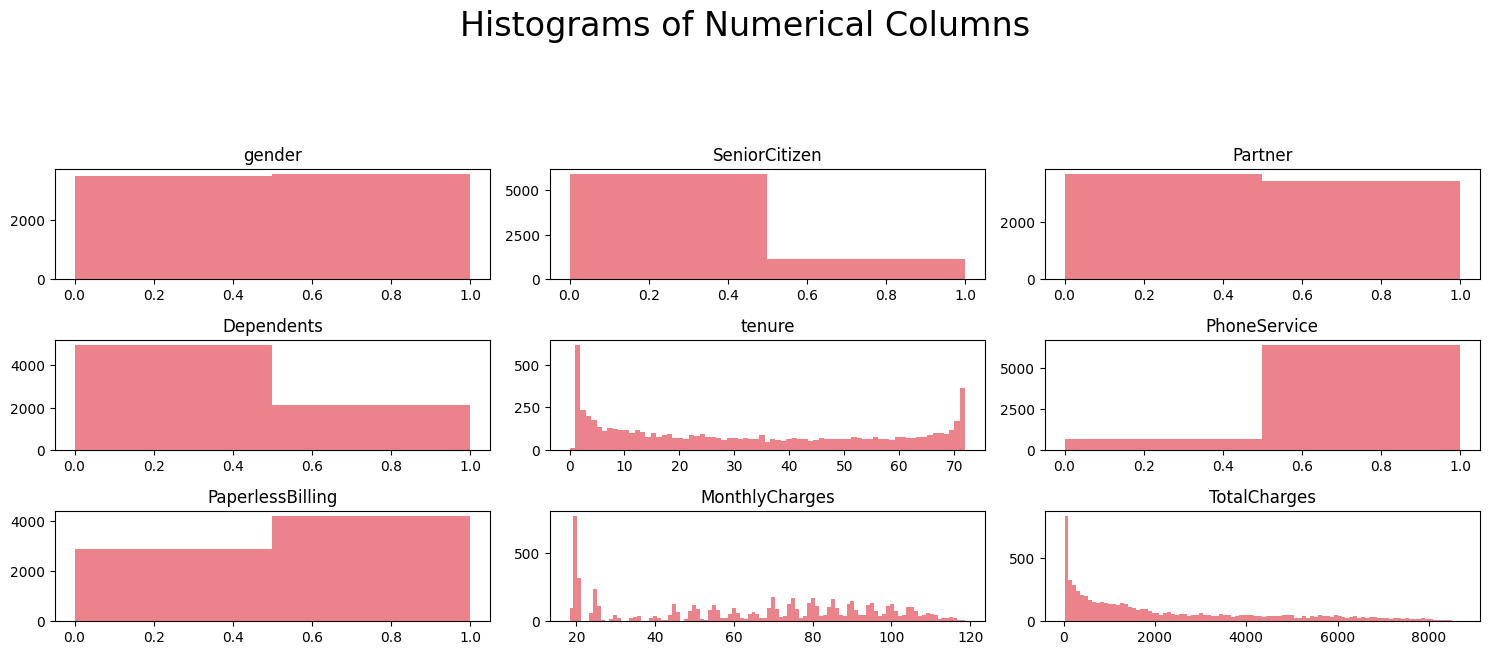

In [27]:
fig = plt.figure(figsize=(15,12))
plt.suptitle('Histograms of Numerical Columns\n',horizontalalignment="center",fontstyle = "normal", fontsize = 24, fontfamily = "sans-serif")
for i in range(dataset2.shape[1]):
    plt.subplot(6,3,i+1)
    f = plt.gca()
    f.set_title(dataset2.columns.values[i])
    vals = np.size(dataset2.iloc[:, i].unique())
    if vals >= 100:
        vals = 100
    
    plt.hist(dataset2.iloc[:, i], bins=vals, color = '#ec838a')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    
contract_split = dataset[[ "customerID", "Contract"]]
contract_split = contract_split.groupby ("Contract")['customerID'].count().reset_index()   
# contract_split.rename({'customerID': 'No. of customers'}, inplace = True)
contract_split.rename(columns={'customerID':'No. of customers'}, inplace=True)

(array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.,
        4500.]),
 [Text(0, 0.0, '0'),
  Text(0, 500.0, '500'),
  Text(0, 1000.0, '1000'),
  Text(0, 1500.0, '1500'),
  Text(0, 2000.0, '2000'),
  Text(0, 2500.0, '2500'),
  Text(0, 3000.0, '3000'),
  Text(0, 3500.0, '3500'),
  Text(0, 4000.0, '4000'),
  Text(0, 4500.0, '4500')])

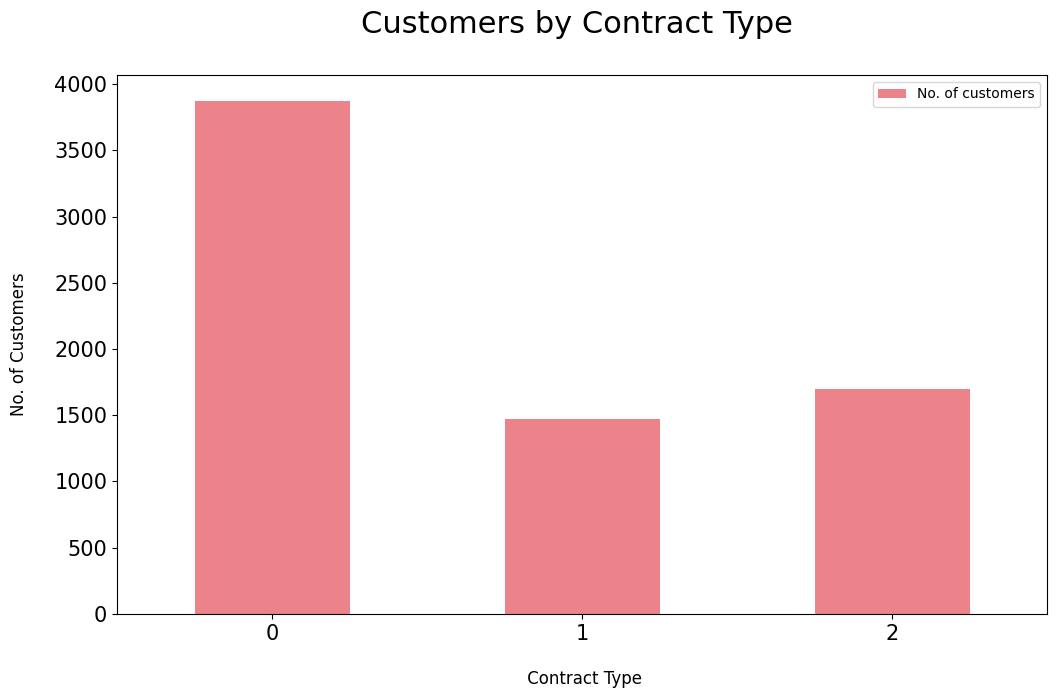

In [28]:
ax =  contract_split[["No. of customers"]].plot.bar(title = 'Customers by Contract Type', legend =True, table = False, grid = False,  subplots = False,  figsize =(12, 7), color ='#ec838a', fontsize = 15, stacked=False)
plt.ylabel('No. of Customers\n',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('\n Contract Type',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.title('Customers by Contract Type \n',horizontalalignment="center", fontstyle = "normal", fontsize = "22", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

In [29]:
x_labels = np.array(contract_split[["No. of customers"]])

In [30]:
def add_value_labels(ax, spacing=5):   
    for rect in ax.patches:      
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2       
        space = spacing        
        va = 'bottom'      
        if y_value < 0:           
            space *= -1            
            va = 'top'       
        label = "{:.0f}".format(y_value)      
        ax.annotate(
            label,                      
            (x_value, y_value),         
            xytext=(0, space),          
            textcoords="offset points", 
            ha='center',                
            va=va)                                                             
add_value_labels(ax)

2) Distribution of Payment Method Type---------------------------------------------------------------------------------------

In [31]:
payment_method_split = dataset[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split  .groupby ("PaymentMethod")
payment_method_split  = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(columns={'customerID':'No. of customers'}, inplace=True)

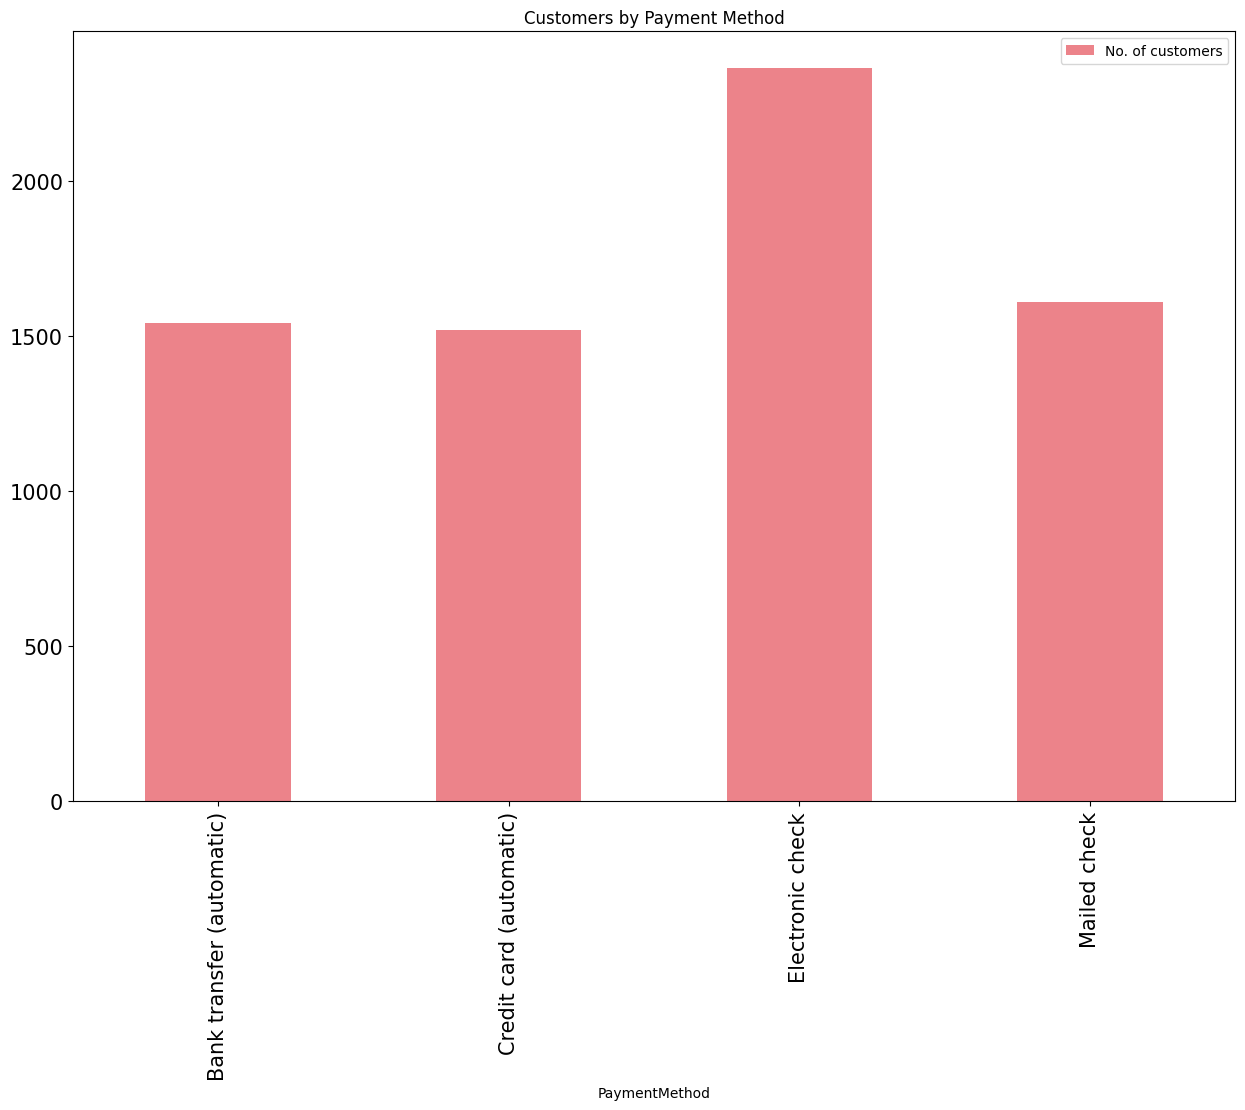

In [32]:
ax =  payment_method_split [["No. of customers"]].plot.bar(title = 'Customers by Payment Method', legend =True, table = False, grid = False,  subplots = False,  figsize =(15, 10), color ='#ec838a', fontsize = 15, stacked=False)

In [33]:
x_labels = np.array(payment_method_split [["No. of customers"]])

In [34]:
add_value_labels(ax)

In [35]:
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

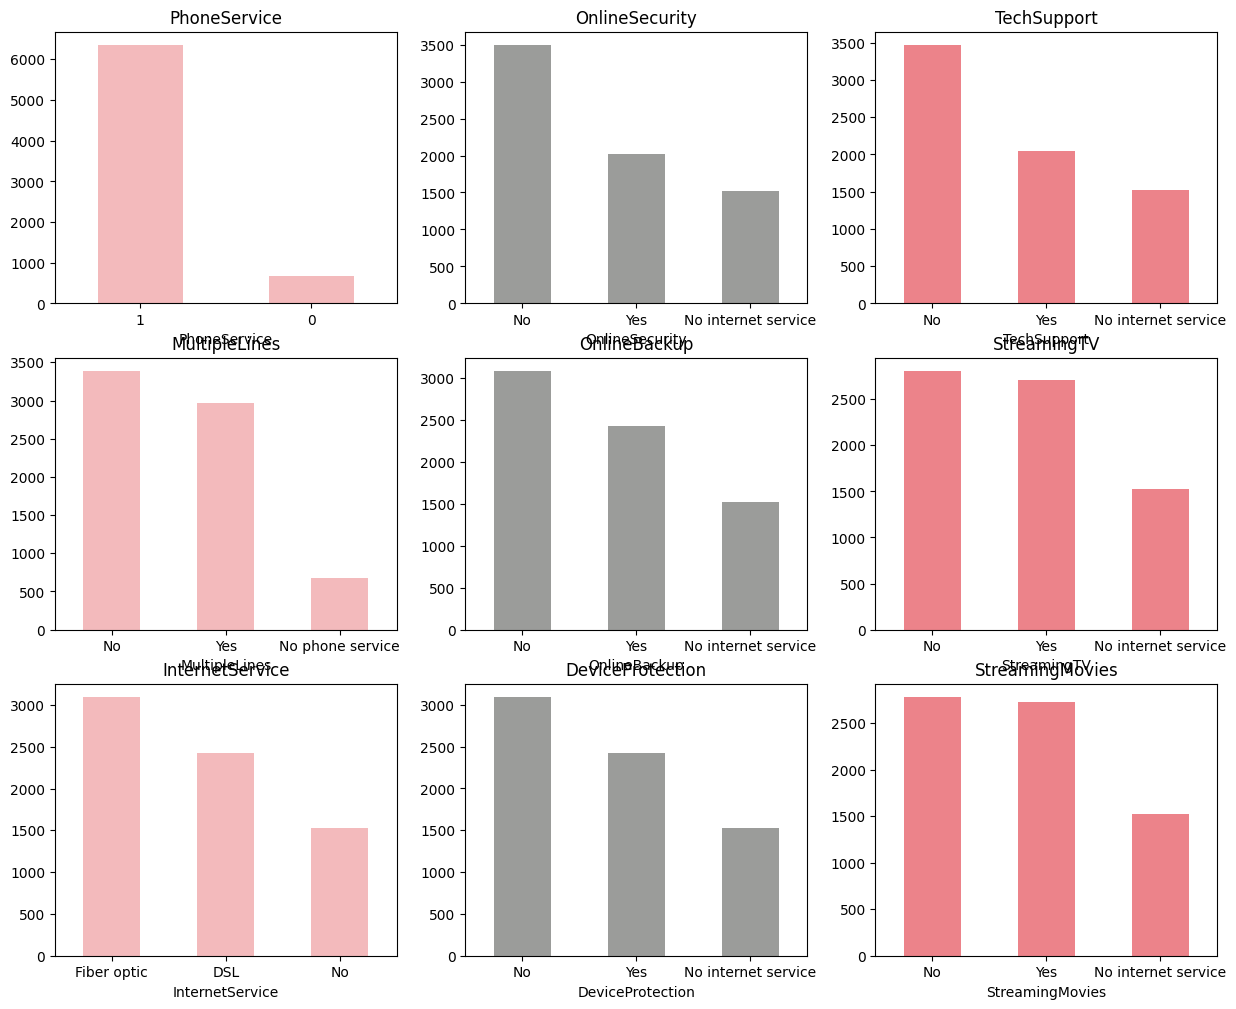

In [36]:
fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
    if i < 3:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0, color ='#f3babc' )
        
    elif i >=3 and i < 6:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0,color ='#9b9c9a')
        
    elif i < 9:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0,color = '#ec838a')
    ax.set_title(item)
    
    
#Step 9.3: Analyze Churn Rate by Categorical variables:   -------------------------------------------------------------

1) Overall Churn Rate------------------------------------------------------------------------------------------

C:\Users\Pavan\AppData\Local\Temp\ipykernel_27224\200772041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churn_rate ["churn_label"] = pd.Series(np.where((churn_rate["Churn"] == 0), "No", "Yes"))


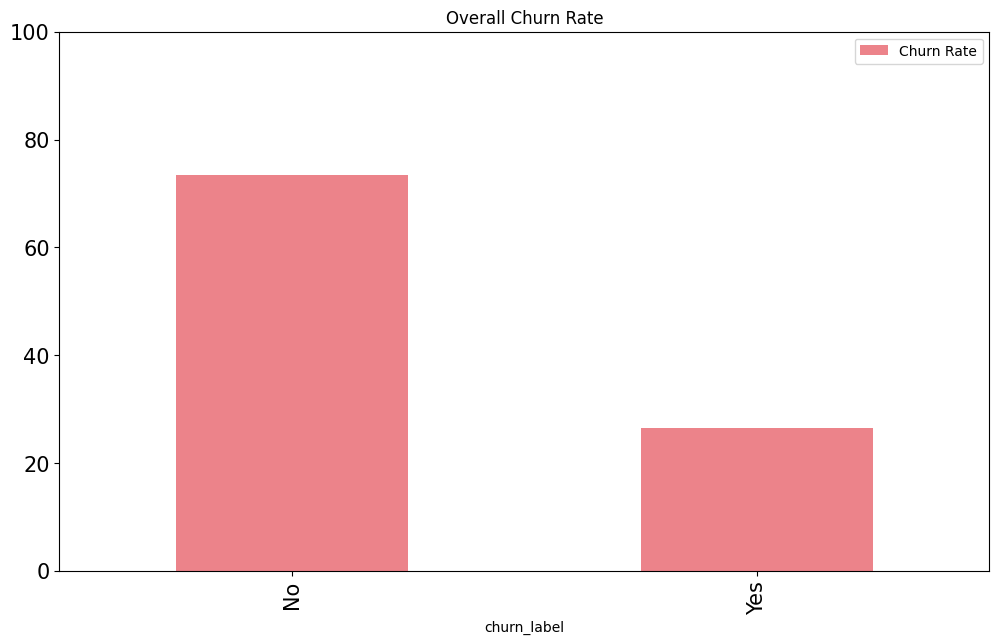

In [37]:
import matplotlib.ticker as mtick
churn_rate = dataset[["Churn", "customerID"]]
churn_rate ["churn_label"] = pd.Series(np.where((churn_rate["Churn"] == 0), "No", "Yes"))
sectors = churn_rate .groupby ("churn_label")
churn_rate = pd.DataFrame(sectors["customerID"].count())
churn_rate ["Churn Rate"] = (churn_rate ["customerID"] / sum(churn_rate ["customerID"]) )*100
ax =  churn_rate[["Churn Rate"]].plot.bar(title = 'Overall Churn Rate', legend =True, table = False, grid = False,  subplots = False,  figsize =(12, 7), color = '#ec838a', fontsize = 15, stacked=False, ylim =(0,100))

C:\Users\Pavan\AppData\Local\Temp\ipykernel_27224\3813712923.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize = "medium")


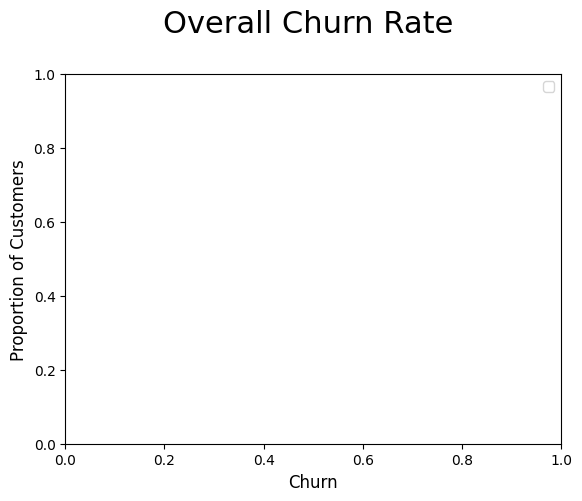

In [38]:
plt.ylabel('Proportion of Customers',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Churn',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.title('Overall Churn Rate \n',horizontalalignment="center", fontstyle = "normal", fontsize = "22", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
x_labels = np.array(churn_rate[["customerID"]])

In [39]:
add_value_labels(ax)
ax.autoscale(enable=False, axis='both', tight=False)

Churn rate by contract type<br>
tack bar chart

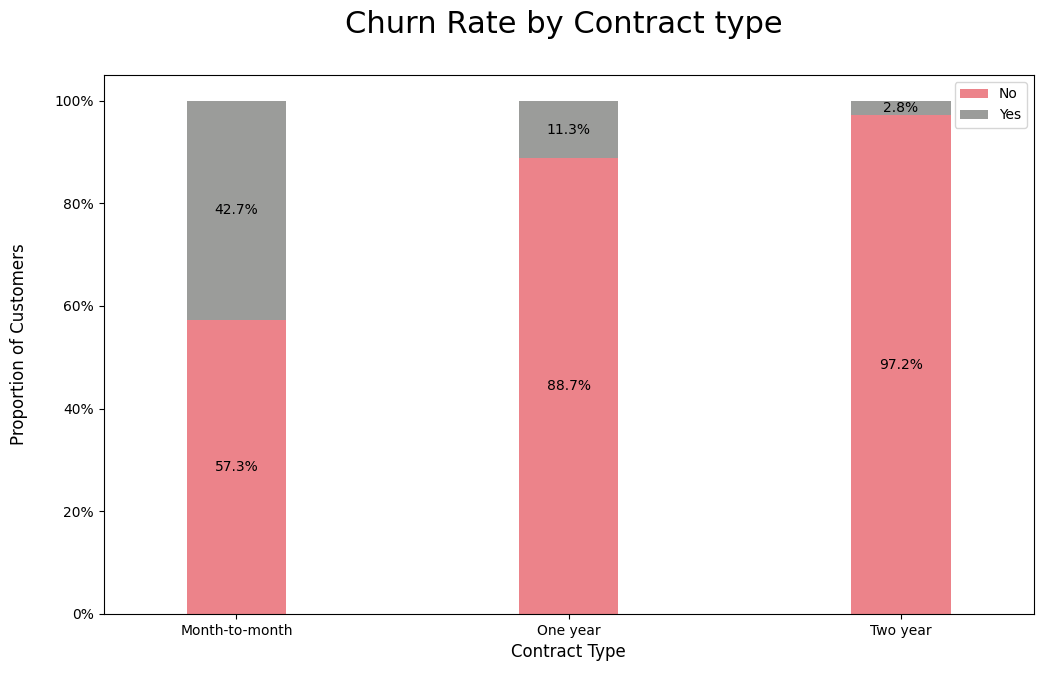

In [40]:
import matplotlib.ticker as mtick
contract_churn =dataset.groupby(
['Contract','Churn']).size().unstack()
contract_churn.rename(
columns={0:'No', 1:'Yes'}, inplace=True)
colors  = ['#ec838a','#9b9c9a']
ax = (contract_churn.T*100.0 / contract_churn.T.sum()).T.plot(kind='bar',width = 0.3,stacked = True,rot = 0,figsize = (12,7),color = colors)
plt.ylabel('Proportion of Customers\n',
horizontalalignment="center",fontstyle = "normal", 
fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Contract Type\n',horizontalalignment="center",
fontstyle = "normal", fontsize = "large", 
fontfamily = "sans-serif")
plt.title('Churn Rate by Contract type \n',
horizontalalignment="center", fontstyle = "normal", 
fontsize = "22", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.text(x+width/2, 
            y+height/2, 
            '{:.1f}%'.format(height), 
            horizontalalignment='center', 
            verticalalignment='center')
ax.autoscale(enable=False, axis='both', tight=False)

y payment method stack

In [41]:
import matplotlib.ticker as mtick
contract_churn = dataset.groupby(['Contract',
'PaymentMethod']).size().unstack()
contract_churn.rename(columns=
{0:'No', 1:'Yes'}, inplace=True)

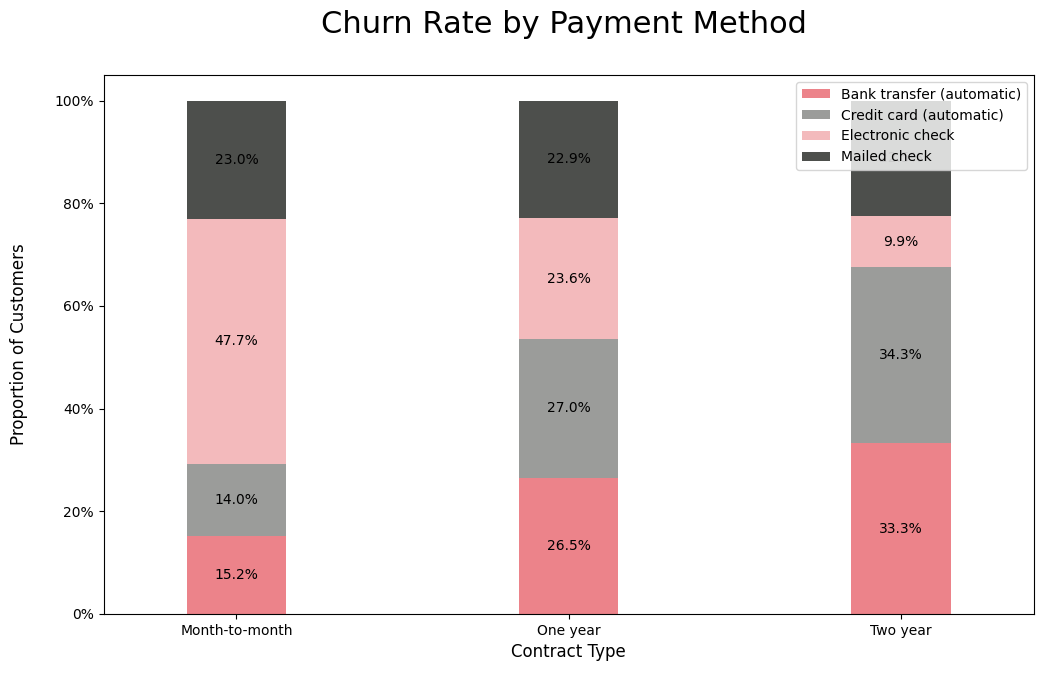

In [42]:
colors  = ['#ec838a','#9b9c9a', '#f3babc' , '#4d4f4c']
ax = (contract_churn.T*100.0 / contract_churn.T.sum()).T.plot(
kind='bar',width = 0.3,stacked = True,rot = 0,figsize = (12,7),
color = colors)
plt.ylabel('Proportion of Customers\n',
horizontalalignment="center",fontstyle = "normal", 
fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Contract Type\n',horizontalalignment="center",
fontstyle = "normal", fontsize = "large", 
fontfamily = "sans-serif")
plt.title('Churn Rate by Payment Method \n',
horizontalalignment="center", fontstyle = "normal", 
fontsize = "22", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.text(x+width/2, 
            y+height/2, 
            '{:.1f}%'.format(height), 
            horizontalalignment='center', 
            verticalalignment='center')
ax.autoscale(enable=False, axis='both', tight=False)

get correlations with churn/target variable

In [43]:
dataset2 = dataset[['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges']]
correlations = dataset2.corrwith(dataset.Churn)
correlations = correlations[correlations!=1]
positive_correlations = correlations[
correlations >0].sort_values(ascending = False)
negative_correlations =correlations[
correlations<0].sort_values(ascending = False)
print('Most Positive Correlations: \n', positive_correlations)
print('\nMost Negative Correlations: \n', negative_correlations)

Most Positive Correlations: 
 MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
dtype: float64

Most Negative Correlations: 
 Partner        -0.150448
Dependents     -0.164221
TotalCharges   -0.199426
tenure         -0.352229
dtype: float64


In [44]:
correlations =  dataset2.corrwith(dataset.Churn)
correlations = correlations[correlations!= -1]

Text(0.5, 1.0, 'Correlation with Churn Rate \n')

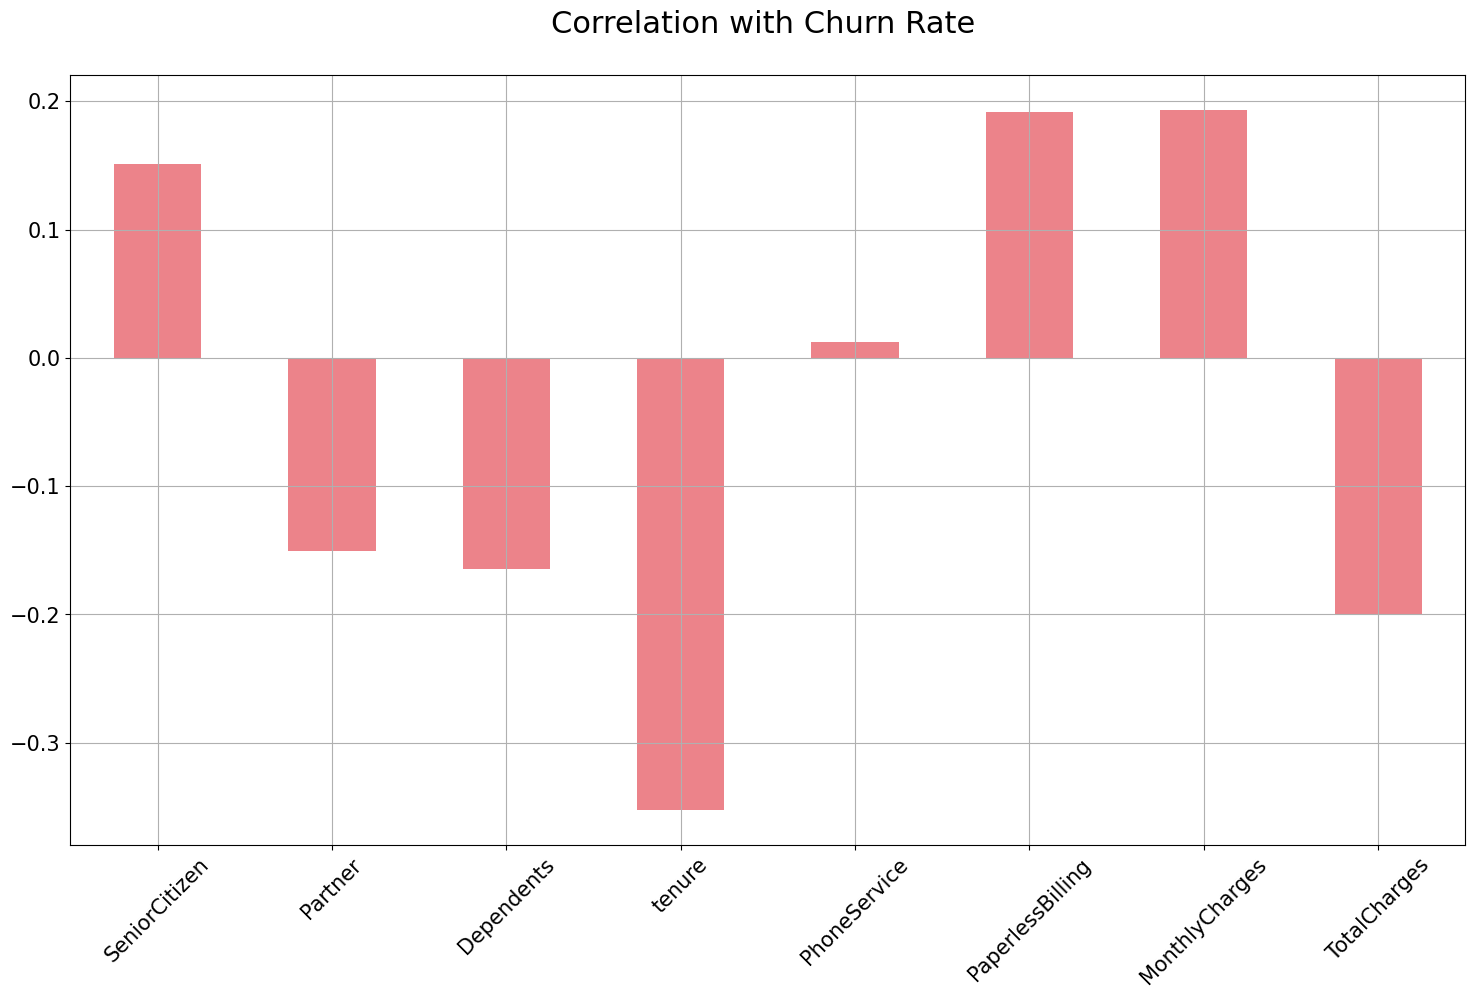

In [45]:
correlations.plot.bar(
        figsize = (18, 10), 
        fontsize = 15, 
        color = '#ec838a',
        rot = 45, grid = True)
plt.title('Correlation with Churn Rate \n',
horizontalalignment="center", fontstyle = "normal", 
fontsize = "22", fontfamily = "sans-serif")

Plot correlation matrix
plot and compute the Correlation Matrix:
plot and compute the Correlation Matrix:

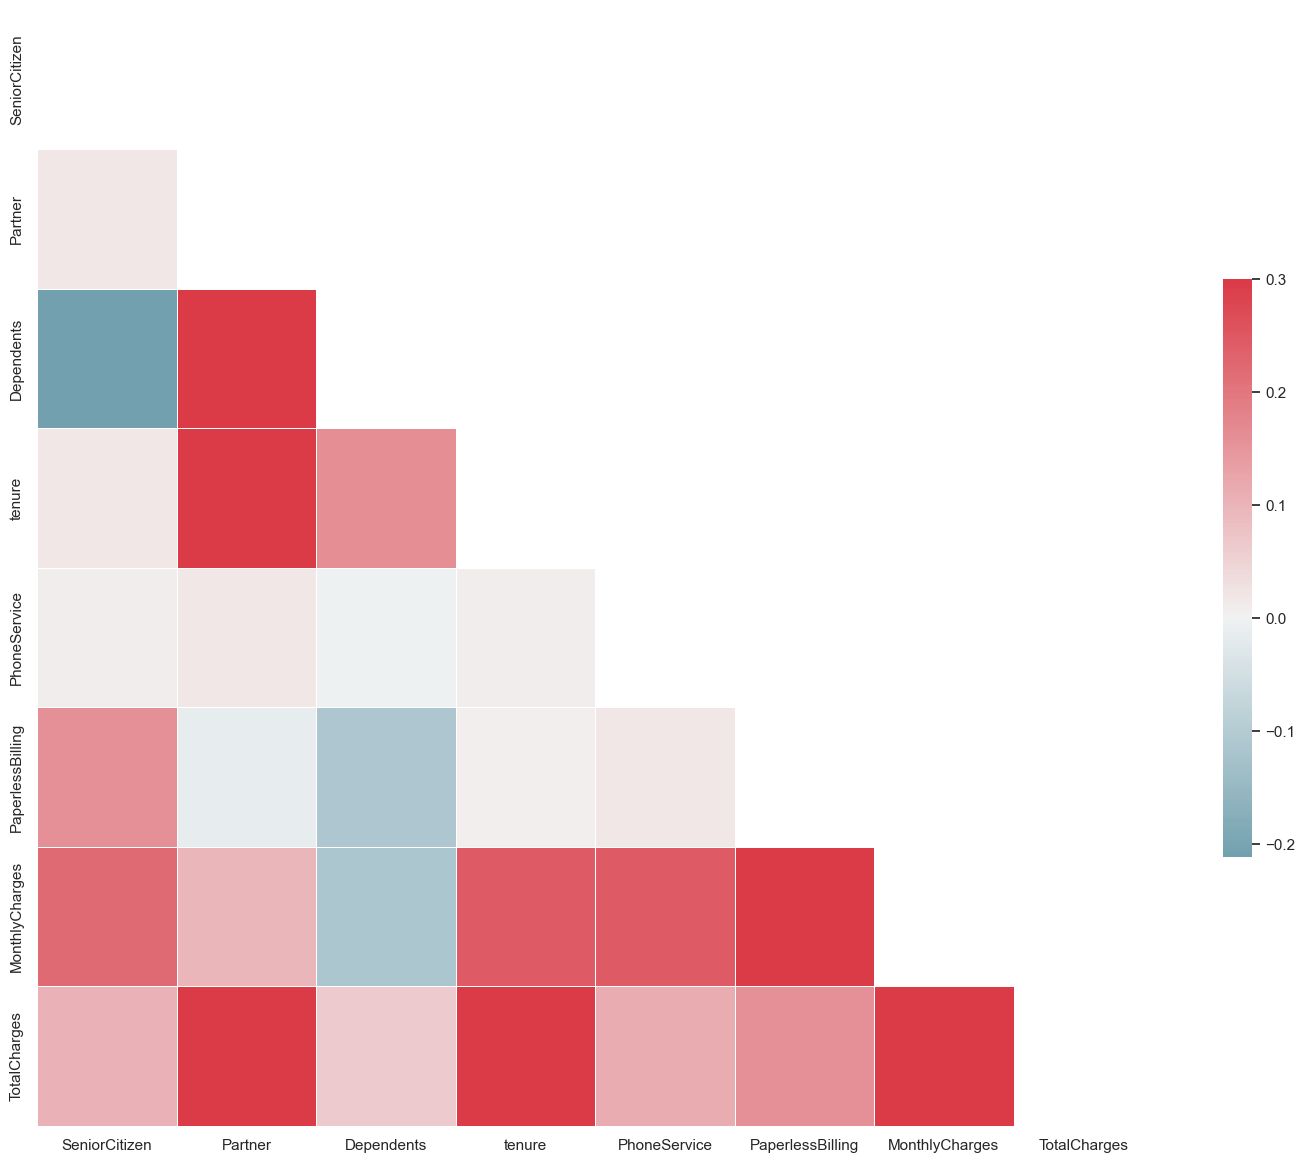

In [46]:
sn.set(style="white")
corr = dataset2.corr()
#Generate a mask for the upper triangle:
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
#Set up the matplotlib figure and a diverging colormap:
f, ax = plt.subplots(figsize=(18, 15))
cmap = sn.diverging_palette(220, 10, as_cmap=True)
#Draw the heatmap with the mask and correct aspect ratio:
sn.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
square=True, linewidths=.5, cbar_kws={"shrink": .5})
corr = dataset2.corr()

Check multi collinearity using VIF

In [47]:
def calc_vif(x):
    #cal vif
    var_df = pd.DataFrame()
    var_df['Columns'] =  x.columns
    var_df['value'] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    return var_df

In [48]:
dataset2 = dataset[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling','MonthlyCharges','TotalCharges']]

In [49]:
calc_vif(dataset2)

,Columns,value
0,gender,1.921286
1,SeniorCitizen,1.327766
2,Partner,2.815272
3,Dependents,1.921208
4,tenure,10.549667
5,PhoneService,7.976386
6,PaperlessBilling,2.814160
7,MonthlyCharges,13.988649
8,TotalCharges,12.570269


Total Charges' seem to be collinear with 'Monthly Charges'.<br>
heck colinearity:

Text(0.5, 1.0, 'Collinearity of Monthly Charges and Total Charges \n')

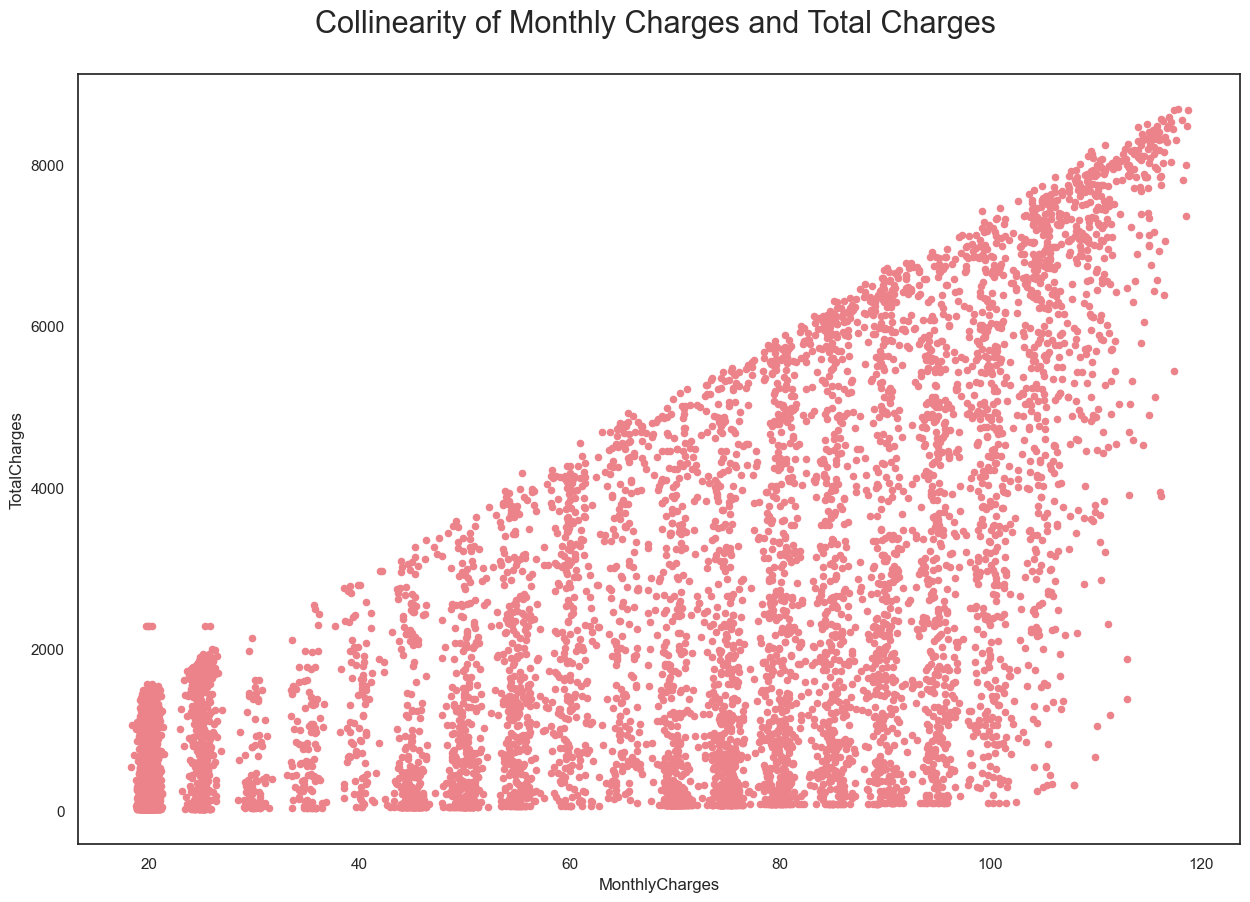

In [50]:
    
dataset2[['MonthlyCharges', 'TotalCharges']].plot.scatter(
figsize = (15, 10), 
x ='MonthlyCharges',
y='TotalCharges', 
color =  '#ec838a')
plt.title('Collinearity of Monthly Charges and Total Charges \n',
horizontalalignment="center", fontstyle = "normal", fontsize = "22", fontfamily = "sans-serif")

Dropping 'TotalCharges':

In [51]:
    
dataset2 = dataset2.drop(columns = "TotalCharges")
#Revalidate Colinearity:
dataset2 = dataset[['gender', 
'SeniorCitizen', 'Partner', 'Dependents',
'tenure', 'PhoneService', 'PaperlessBilling',
'MonthlyCharges']]
calc_vif(dataset2)
#Applying changes in the main dataset:
    
dataset = dataset.drop(columns = "TotalCharges")

Letâ€™s try to summarise some of the key findings from this EDA:<br>
The dataset does not have any missing or erroneous data values.<br>
Strongest positive correlation with the target features is Monthly Charges and Age whilst negative correlation is with Partner, Dependents and Tenure.<br>
The dataset is imbalanced with the majority of customers being active.<br>
There is multicollinearity between Monthly Charges and Total Charges. Dropping Total Charges have decreased the VIF values considerably.<br>
Most of the customers in the dataset are younger people.<br>
There are a lot of new customers in the organization (less than 10 months old) followed by a loyal customer base thatâ€™s above 70 months old.<br>
Most of the customers seem to have phone service with Monthly charges spanning between $18 to $118 per customer.<br>
Customers with a month-to-month connection have a very high probability to churn that too if they have subscribed to pay via electronic checks.

Dropping categorical values<br>
Any column that has more than 2 categroies is categorical

In [52]:
identity =  dataset['customerID']

In [53]:
dataset.drop(columns = ['customerID'], inplace = True)

In [54]:
cat_cols = []


In [55]:
for col in dataset.columns:
    # print(col)<br>
    if dataset[col].dtypes =='object':
        if len(dataset[col].unique())>=2:
            print(col)

MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod


In [56]:
dataset = pd.get_dummies(dataset)

In [57]:
dataset = pd.concat([identity, dataset], axis =1)

In [58]:
response = dataset['Churn']
dataset = dataset.drop(columns=['Churn'])

ploiting into train and test

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(dataset, response, stratify=response, test_size=0.2, random_state=42)
#to resolve any class imbalance - use stratify parameter.
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)
#use startify if the data is imbalanced

Number transactions X_train dataset:  (5634, 40)
Number transactions y_train dataset:  (5634,)
Number transactions X_test dataset:  (1409, 40)
Number transactions y_test dataset:  (1409,)


remove identifier

In [61]:
train_identity = X_train['customerID']
X_train = X_train.drop(columns = ['customerID'])
test_identity = X_test['customerID']
X_test = X_test.drop(columns = ['customerID'])

# Feature Scaling

It is quite important to normalize the variables before conducting any machine learning (classification) algorithms so that all the training and test variables are scaled within a range of 0 to 1.

In [62]:
sc_X = StandardScaler()

In [63]:
X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
X_train2.columns = X_train.columns
X_train2.index = X_train.index.values
X_train = X_train2

In [64]:
X_test2 = pd.DataFrame(sc_X.transform(X_test))
X_test2.columns = X_test.columns.values
X_test2.index = X_test.index.values
X_test = X_test2

# Model Selection 
Evaluate different classification algorithms

## Class Imbalance & Modeling Strategy

The dataset is imbalanced: **73.5% No-Churn vs 26.5% Churn**.
Ignoring this causes models to be biased toward predicting "No Churn" and miss actual churners —
exactly the costly mistake for the business (a missed churner is a lost customer with no retention action taken).

**Approach:**
- `class_weight='balanced'` for sklearn models (internally adjusts sample weights by inverse class frequency)
- `scale_pos_weight` for XGBoost (ratio of majority to minority class)
- Stratified train/test split already applied (cell above)
- F2 Score (β=2) is used as the primary ranking metric: it weights recall **twice** as heavily as precision,
  reflecting that missing a churner is more expensive than a false alarm.

In [65]:
# Class ratio for XGBoost scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = round(neg / pos, 4)
print(f"Class ratio (majority/minority): {scale_pos}")

# Helper: compute all metrics + ROC-AUC for a fitted model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    # Use predict_proba if available, else decision_function
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)
    from sklearn.metrics import (accuracy_score, precision_score,
                                  recall_score, f1_score, fbeta_score,
                                  roc_auc_score)
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_te, y_pred), 4),
        "F1 Score":  round(f1_score(y_te, y_pred), 4),
        "F2 Score":  round(fbeta_score(y_te, y_pred, beta=2.0), 4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_prob), 4),
        "_model":    model,
        "_y_prob":   y_prob,
        "_y_pred":   y_pred,
    }

Class ratio (majority/minority): 2.7686


## Train & Evaluate All Models

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

model_specs = [
    ("Logistic Regression",
     LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ("Naive Bayes",
     GaussianNB()),
    ("Random Forest",
     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ("XGBoost",
     XGBClassifier(scale_pos_weight=scale_pos, random_state=42,
                   eval_metric='logloss', verbosity=0)),
    ("SVC",
     SVC(probability=True, random_state=42, class_weight='balanced')),
    ("K-Nearest Neighbors",
     KNeighborsClassifier(n_neighbors=5)),
    ("Decision Tree",
     DecisionTreeClassifier(random_state=42, class_weight='balanced')),
]

all_results = []
fitted_models = {}

for name, model in model_specs:
    result = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    fitted_models[name] = (result.pop("_model"), result.pop("_y_prob"), result.pop("_y_pred"))
    all_results.append(result)
    print(f"  {name:<25} Acc={result['Accuracy']:.4f}  F2={result['F2 Score']:.4f}  AUC={result['ROC-AUC']:.4f}")

print("\nAll models trained.")

  Logistic Regression       Acc=0.7410  F2=0.7032  AUC=0.8382
  Naive Bayes               Acc=0.6835  F2=0.7198  AUC=0.8082
  Random Forest             Acc=0.7814  F2=0.5095  AUC=0.8105
  XGBoost                   Acc=0.7559  F2=0.6396  AUC=0.8173
  SVC                       Acc=0.7488  F2=0.7000  AUC=0.8188
  K-Nearest Neighbors       Acc=0.7473  F2=0.4984  AUC=0.7658
  Decision Tree             Acc=0.7303  F2=0.5090  AUC=0.6618

All models trained.


## Model Comparison Table

In [67]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("F2 Score", ascending=False).reset_index(drop=True)
print("Models ranked by F2 Score (recall-weighted):\n")
print(results_df.to_string(index=False))

Models ranked by F2 Score (recall-weighted):

              Model  Accuracy  Precision  Recall  F1 Score  F2 Score  ROC-AUC
        Naive Bayes    0.6835     0.4490  0.8476    0.5870    0.7198   0.8082
Logistic Regression    0.7410     0.5079  0.7781    0.6146    0.7032   0.8382
                SVC    0.7488     0.5181  0.7674    0.6185    0.7000   0.8188
            XGBoost    0.7559     0.5316  0.6738    0.5943    0.6396   0.8173
      Random Forest    0.7814     0.6100  0.4893    0.5430    0.5095   0.8105
      Decision Tree    0.7303     0.4923  0.5134    0.5026    0.5090   0.6618
K-Nearest Neighbors    0.7473     0.5257  0.4920    0.5083    0.4984   0.7658


## ROC Curves — All Models

The ROC curve plots True Positive Rate vs False Positive Rate at every classification threshold.
AUC (Area Under the Curve) summarises this in a single number: 1.0 is perfect, 0.5 is random.

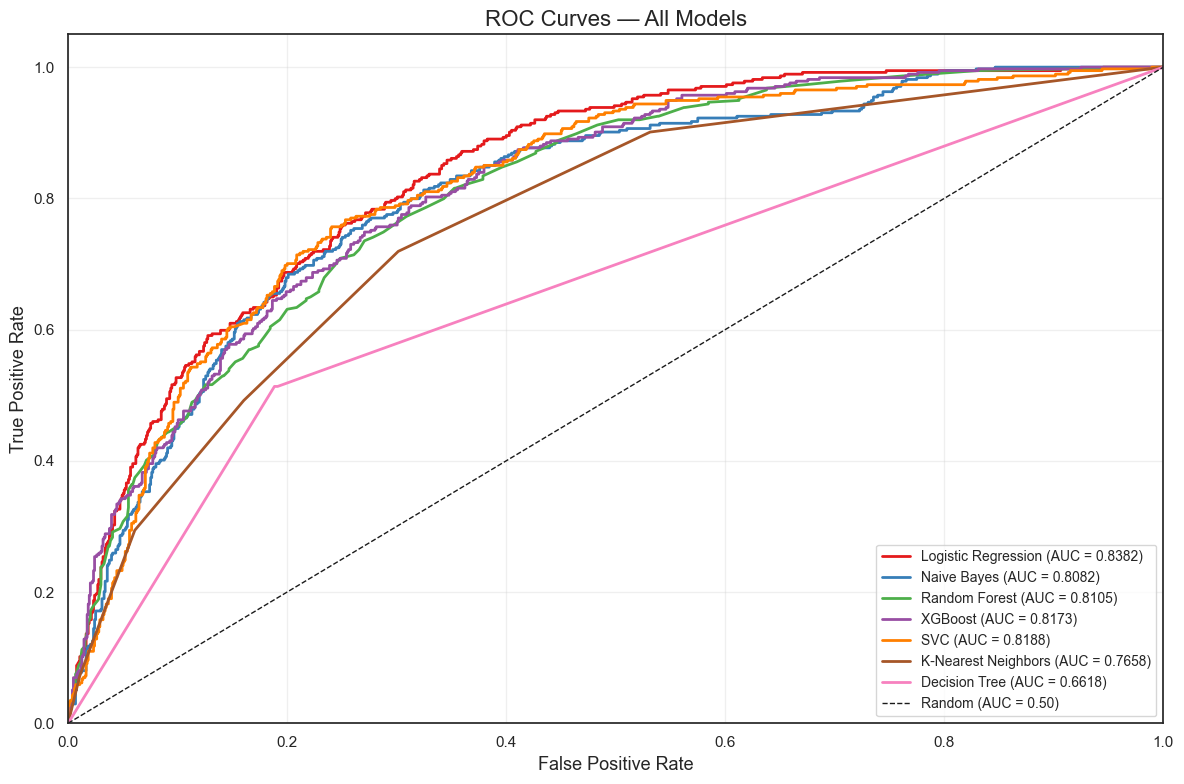

In [68]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']
for (name, (model, y_prob, _)), color in zip(fitted_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = [r["ROC-AUC"] for r in all_results if r["Model"] == name][0]
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves — All Models", fontsize=16)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrix — Best Model by F2 Score

The best model by F2 Score is chosen because **F2 weights recall twice as heavily as precision**.
In churn prediction, a **False Negative** (missing a churner) costs far more than a **False Positive**
(erroneously flagging a loyal customer for a retention offer).
A missed churner = lost subscription revenue, possibly indefinitely.
A false alarm = minor cost of a retention offer sent to someone who wasn't going to leave.

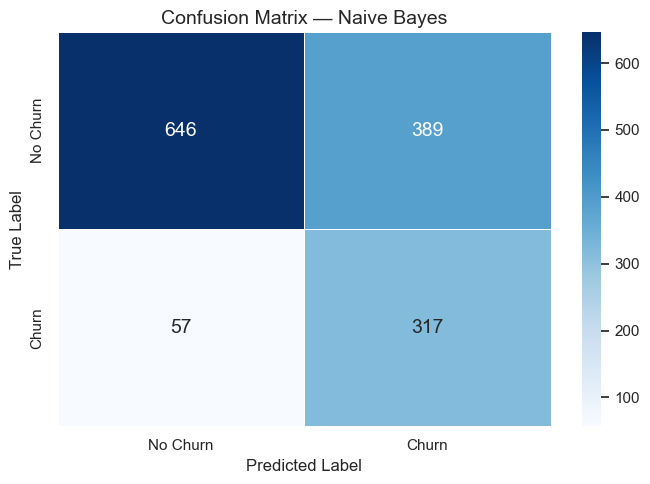

True Positives  (churners caught):    317
False Negatives (churners missed):    57  ← costly
False Positives (false alarms):       389
True Negatives  (correctly retained): 646


In [69]:
from sklearn.metrics import confusion_matrix

best_model_name = results_df.iloc[0]["Model"]
_, _, y_pred_best = fitted_models[best_model_name]

cm = confusion_matrix(y_test, y_pred_best)
cm_labels = ["No Churn", "Churn"]

fig, ax = plt.subplots(figsize=(7, 5))
sn.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=cm_labels, yticklabels=cm_labels,
           linewidths=0.5, ax=ax, annot_kws={"size": 14})
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (churners caught):    {tp}")
print(f"False Negatives (churners missed):    {fn}  ← costly")
print(f"False Positives (false alarms):       {fp}")
print(f"True Negatives  (correctly retained): {tn}")

## 5-Fold Cross-Validation — Top 2 Models by F2 Score

A single train/test split can be misleading — the model might have gotten lucky (or unlucky) with
that particular 20% of the data. K-Fold cross-validation partitions the data into k=5 non-overlapping
folds, trains on 4 and tests on 1 repeatedly, and averages the scores.

**Why this matters:** Mean ± Std across 5 folds shows whether the model is consistently good
or just performing well on one lucky split. High standard deviation → unstable model.

In [70]:
from sklearn.model_selection import KFold, cross_val_score

top2_names = list(results_df.head(2)["Model"])
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation (F1 Score):")
print("-" * 50)
for name in top2_names:
    model_obj, _, _ = fitted_models[name]
    # Combine train+test for CV (use full X after scaling)
    X_full = pd.concat([X_train, X_test])
    y_full = pd.concat([y_train, y_test])
    scores = cross_val_score(model_obj.__class__(**model_obj.get_params()),
                             X_full, y_full, cv=kf, scoring="f1")
    print(f"  {name:<25} F1 = {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[round(s,4) for s in scores]}")

5-Fold Cross-Validation (F1 Score):
--------------------------------------------------
  Naive Bayes               F1 = 0.5917 ± 0.0108
    Fold scores: [0.5806, 0.592, 0.5893, 0.5848, 0.6119]
  Logistic Regression       F1 = 0.6280 ± 0.0097
    Fold scores: [0.6129, 0.629, 0.6237, 0.6425, 0.6321]


## Hyperparameter Tuning — GridSearchCV

GridSearchCV exhaustively tries all combinations in a parameter grid using cross-validation
to find the setting that maximises a chosen metric (here: F2 score, favouring recall).
Applied to the top model by F2 Score from the initial comparison.

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

best_name = results_df.iloc[0]["Model"]
best_model_obj, _, _ = fitted_models[best_name]
f2_scorer = make_scorer(fbeta_score, beta=2.0)

# Parameter grid for the best model type
if best_name == "Random Forest":
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    }
elif best_name == "XGBoost":
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 6],
        "learning_rate": [0.05, 0.1],
    }
elif best_name == "Logistic Regression":
    param_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
        "solver": ["lbfgs", "liblinear"],
    }
elif best_name == "Decision Tree":
    param_grid = {
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
    }
elif best_name == "SVC":
    param_grid = {
        "C": [0.1, 1.0, 10.0],
        "kernel": ["rbf", "linear"],
    }
elif best_name == "Naive Bayes":
    param_grid = {"var_smoothing": [1e-9, 1e-7, 1e-5]}
else:
    param_grid = {"n_neighbors": [3, 5, 7, 11]}

print(f"Running GridSearchCV on: {best_name}")
print(f"Parameter grid: {param_grid}")

gs = GridSearchCV(
    best_model_obj.__class__(**best_model_obj.get_params()),
    param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
)
gs.fit(X_train, y_train)
print(f"\nBest params: {gs.best_params_}")
print(f"Best CV F2:  {gs.best_score_:.4f}")

Running GridSearchCV on: Naive Bayes
Parameter grid: {'var_smoothing': [1e-09, 1e-07, 1e-05]}

Best params: {'var_smoothing': 1e-09}
Best CV F2:  0.7260


In [72]:
# Evaluate tuned model on held-out test set
y_pred_tuned = gs.best_estimator_.predict(X_test)
if hasattr(gs.best_estimator_, "predict_proba"):
    y_prob_tuned = gs.best_estimator_.predict_proba(X_test)[:, 1]
else:
    y_prob_tuned = gs.best_estimator_.decision_function(X_test)

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, fbeta_score, roc_auc_score)

tuned_row = {
    "Model":     f"{best_name} (Tuned)",
    "Accuracy":  round(accuracy_score(y_test, y_pred_tuned), 4),
    "Precision": round(precision_score(y_test, y_pred_tuned, zero_division=0), 4),
    "Recall":    round(recall_score(y_test, y_pred_tuned), 4),
    "F1 Score":  round(f1_score(y_test, y_pred_tuned), 4),
    "F2 Score":  round(fbeta_score(y_test, y_pred_tuned, beta=2.0), 4),
    "ROC-AUC":   round(roc_auc_score(y_test, y_prob_tuned), 4),
}

# Store tuned model for serialisation in next commit
fitted_models[tuned_row["Model"]] = (gs.best_estimator_, y_prob_tuned, y_pred_tuned)

# Add to comparison table
final_results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_row])],
    ignore_index=True
).sort_values("F2 Score", ascending=False).reset_index(drop=True)

print("\n=== FINAL MODEL COMPARISON (sorted by F2 Score) ===")
print(final_results_df.to_string(index=False))


=== FINAL MODEL COMPARISON (sorted by F2 Score) ===
              Model  Accuracy  Precision  Recall  F1 Score  F2 Score  ROC-AUC
        Naive Bayes    0.6835     0.4490  0.8476    0.5870    0.7198   0.8082
Naive Bayes (Tuned)    0.6835     0.4490  0.8476    0.5870    0.7198   0.8082
Logistic Regression    0.7410     0.5079  0.7781    0.6146    0.7032   0.8382
                SVC    0.7488     0.5181  0.7674    0.6185    0.7000   0.8188
            XGBoost    0.7559     0.5316  0.6738    0.5943    0.6396   0.8173
      Random Forest    0.7814     0.6100  0.4893    0.5430    0.5095   0.8105
      Decision Tree    0.7303     0.4923  0.5134    0.5026    0.5090   0.6618
K-Nearest Neighbors    0.7473     0.5257  0.4920    0.5083    0.4984   0.7658


## Final Model Recommendation

The table above ranks all models by **F2 Score**, which penalises missed churners more than
false alarms (β=2 doubles the weight on recall relative to precision).

**Recommended production model:** The tuned version of whichever model ranks #1 above.

**Business justification:**
In telecom churn, the cost asymmetry is clear:
- A **False Negative** (churner we didn't catch) = lost subscription revenue — potentially months
  or years of recurring income — with zero chance to intervene.
- A **False Positive** (loyal customer flagged as at-risk) = minor cost of a retention offer
  (e.g. a discount SMS or 15-min call from customer service), easily absorbed.

The best model should therefore maximise **recall on the churn class** while maintaining
reasonable precision so retention resources aren't completely wasted.
ROC-AUC provides a threshold-independent measure to confirm discriminative ability.

The final tuned model will be serialised in the next step for use in `predict.py`.

## Model Serialization

Save the final tuned model, the fitted StandardScaler, and the post-OHE feature column list
to `../models/`. These three artefacts are everything needed to make predictions on new data
without re-running the full notebook.

In [73]:
import joblib, os

MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# The tuned model is the top-ranked entry in final_results_df
final_model_name = final_results_df.iloc[0]["Model"]
final_model_obj, _, _ = fitted_models[final_model_name]

# Save artefacts
joblib.dump(final_model_obj, os.path.join(MODELS_DIR, "best_model.pkl"))
joblib.dump(sc_X,            os.path.join(MODELS_DIR, "scaler.pkl"))
joblib.dump(list(X_train.columns), os.path.join(MODELS_DIR, "feature_columns.pkl"))

print(f"Model saved:    models/best_model.pkl  ({final_model_name})")
print(f"Scaler saved:   models/scaler.pkl")
print(f"Columns saved:  models/feature_columns.pkl  ({len(X_train.columns)} features)")

Model saved:    models/best_model.pkl  (Naive Bayes)
Scaler saved:   models/scaler.pkl
Columns saved:  models/feature_columns.pkl  (39 features)
